*   the goal of this project is to analyze diabetes data
*   pick any **group** in this dataset as an **initial comparison point**
*   pick **a feature/measure/indicator**
*   **compare above group to any other (different) group  - one additional group comparison**
*   some **descriptive statistics**, **one cleaning task** (or more), **one visualization** (or more)
*   a **brief conclusion statement** (not more than two or three sentences)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
df= pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')
pd.set_option('display.max_columns', None)#display all columns
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
df.info()
# NO NULL VALUE + all columns
#age, weight, max_glu_serum, A1Cresult (OBJECT)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [3]:
#import data and replace missing values in place
missing_values = ["?",'nan',"NA", "N/A", "", "None"]
df= pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv', na_values=missing_values)
df.head()

/tmp/ipykernel_148156/3021383160.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv', na_values=missing_values)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
# check values of potential columns.....'nan','?'
for col in df[['race', 'gender','age','weight','max_glu_serum','A1Cresult','change','glyburide','diabetesMed','readmitted']]:
    print(f"'>'{col}': {df[col].unique()}")
#“up” if the dosage was increased during the encounter,
#“down” if the dosage was decreased,
#“steady” if the dosage did not change
#“no” if the drug was not prescribed

'>'race': ['Caucasian' 'AfricanAmerican' nan 'Other' 'Asian' 'Hispanic']
'>'gender': ['Female' 'Male' 'Unknown/Invalid']
'>'age': ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
'>'weight': [nan '[75-100)' '[50-75)' '[0-25)' '[100-125)' '[25-50)' '[125-150)'
 '[175-200)' '[150-175)' '>200']
'>'max_glu_serum': [nan '>300' 'Norm' '>200']
'>'A1Cresult': [nan '>7' '>8' 'Norm']
'>'change': ['No' 'Ch']
'>'glyburide': ['No' 'Steady' 'Up' 'Down']
'>'diabetesMed': ['No' 'Yes']
'>'readmitted': ['NO' '>30' '<30']


In [8]:
# missing values in perentage
pd.DataFrame({'nan_count': df.isna().sum(),
    'nan_%': df.isna().mean() * 100})

#             nan_count nan_%
#weight                  97
#max_glu_serum	96420	   95
#A1Cresult	    84748	   83

#columns over 90% of missing values.

,nan_count,nan_%
encounter_id,0,0.000000
patient_nbr,0,0.000000
race,0,0.000000
gender,0,0.000000
age,0,0.000000
weight,98569,96.858479
admission_type_id,0,0.000000
discharge_disposition_id,0,0.000000
admission_source_id,0,0.000000
time_in_hospital,0,0.000000


In [6]:
df['age'] = df['age'].str.strip('[)')
#strip unwanted characters

In [7]:
#replace value nan to 'Other'
df['race'] = df['race'].fillna('Other')
df['race'].value_counts()


,count
race,
Caucasian,76099
AfricanAmerican,19210
Other,3779
Hispanic,2037
Asian,641


In [113]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [9]:
drop = ['weight','payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses','max_glu_serum', 'A1Cresult','metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone']
df1 = df.drop(drop,axis = 1).copy()
df1.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,0-10,6,25,1,1,No,No,NO
1,149190,55629189,Caucasian,Female,10-20,1,1,7,3,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,20-30,1,1,7,2,No,Yes,NO
3,500364,82442376,Caucasian,Male,30-40,1,1,7,2,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,40-50,1,1,7,1,Ch,Yes,NO


In [10]:
#create a df, count of visits by individual patient. agg columns and save into new df
df_patient = df1.groupby('patient_nbr').agg({
    'encounter_id': 'count',
    'age': 'first',#save first value appear in dataset
    'gender': 'first',
    'race':'first',
    'time_in_hospital':'sum',
    'diabetesMed': lambda x: (x == 'Yes').any()# if at least one record for each patient contains 'Yes' in the diabetesMed column
}).reset_index()#Converts Index to Column

df_patient.rename(columns={'encounter_id': 'visit_count'}, inplace=True)

In [11]:
df_patient = df_patient.sort_values(by='age',ascending=True)
df_patient.head()

,patient_nbr,visit_count,age,gender,race,time_in_hospital,diabetesMed
16769,22897152,1,0-10,Female,Caucasian,2,True
12190,13901463,1,0-10,Female,Caucasian,4,True
2529,1091331,1,0-10,Male,Caucasian,3,True
3630,1735551,1,0-10,Male,Asian,1,True
48758,79701975,1,0-10,Male,Caucasian,2,True


In [12]:
df_patient.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71518 entries, 16769 to 18359
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   patient_nbr       71518 non-null  int64 
 1   visit_count       71518 non-null  int64 
 2   age               71518 non-null  object
 3   gender            71518 non-null  object
 4   race              71518 non-null  object
 5   time_in_hospital  71518 non-null  int64 
 6   diabetesMed       71518 non-null  bool  
dtypes: bool(1), int64(3), object(3)
memory usage: 3.9+ MB


In [13]:
#change data type of column to string
df_patient['diabetesMed'] = df_patient['diabetesMed'].astype(str)

In [14]:
#replace strings 'True' and 'False' with 'Yes' and 'No'
df_patient['diabetesMed'] = df_patient['diabetesMed'].replace({
    'True': 'Yes',
    'False': 'No'})
df_patient.head()

,patient_nbr,visit_count,age,gender,race,time_in_hospital,diabetesMed
16769,22897152,1,0-10,Female,Caucasian,2,Yes
12190,13901463,1,0-10,Female,Caucasian,4,Yes
2529,1091331,1,0-10,Male,Caucasian,3,Yes
3630,1735551,1,0-10,Male,Asian,1,Yes
48758,79701975,1,0-10,Male,Caucasian,2,Yes


In [15]:
#count patients taking DM med by age
df_patient.groupby('diabetesMed')['age'].value_counts()

diabetesMed  age   
No           70-80      3780
             60-70      3178
             80-90      2751
             50-60      2596
             40-50      1488
             30-40       662
             90-100      558
             20-30       234
             10-20        69
             0-10         24
Yes          70-80     14430
             60-70     12782
             50-60      9870
             80-90      8838
             40-50      5390
             30-40      2037
             90-100     1342
             20-30       893
             10-20       466
             0-10        130
Name: count, dtype: int64

Text(0.5, 1.04, 'amount of patient that take DM med')

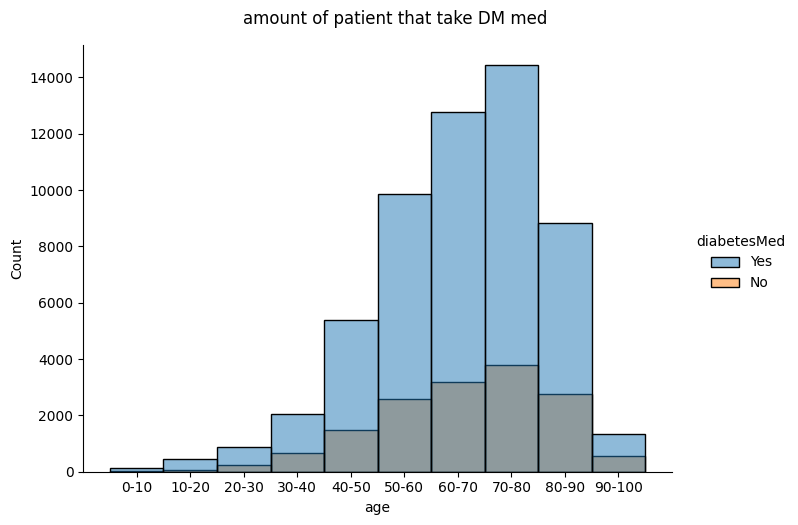

In [112]:
#map count of patients taking DM med by age
a = sns.displot(data=df_patient,
                x='age',
                aspect=1.4,
                hue = 'diabetesMed')
a.fig.suptitle('amount of patient that on DM med',y=1.04)

The distribution skewed to the left. The age geoup of 70-80 have the most number of diabetic patients, following by the age group of 60-70, then the group of 50-60.

Text(0.5, 1.04, 'amount of patient that on/not on DM med by age and gender')

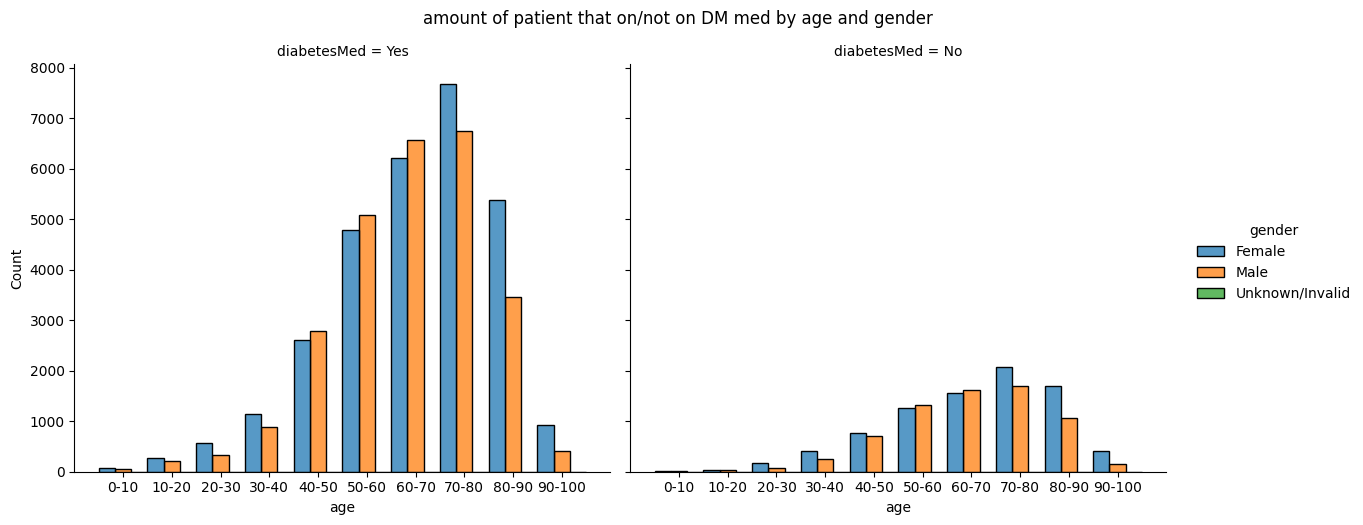

In [55]:
c = sns.displot(data=df_patient,
                x='age',
                hue = 'gender',
                col='diabetesMed',
                #y='gender',
                multiple='dodge',
                aspect=1.2)
c.fig.suptitle('amount of patient that on/not on DM med by age and gender',y=1.04)

add a third variable(gender) to the displot. In the groups of patients aged between 40-70, the amount of male patients who are on med is higher than female patients. Whereas the ratio of female patients who aged after 70 is higher than male patients.

In [16]:
df_patient.groupby('diabetesMed')[['visit_count','time_in_hospital']].describe()

visit_count                                                \
                  count      mean       std  min  25%  50%  75%   max   
diabetesMed                                                             
No              15340.0  1.157757  0.583261  1.0  1.0  1.0  1.0  11.0   
Yes             56178.0  1.495354  1.182053  1.0  1.0  1.0  2.0  40.0   

            time_in_hospital                                                 
                       count      mean       std  min  25%  50%  75%    max  
diabetesMed                                                                  
No                   15340.0  4.695698  4.519709  1.0  2.0  3.0  6.0   70.0  
Yes                  56178.0  6.681085  6.925248  1.0  3.0  5.0  8.0  180.0

In [17]:
df_patient.groupby('diabetesMed')[['visit_count','time_in_hospital']].count()

,visit_count,time_in_hospital
diabetesMed,,
No,15340,15340
Yes,56178,56178


Text(0.5, 1.04, 'correlation of time of visits and time in hospital')

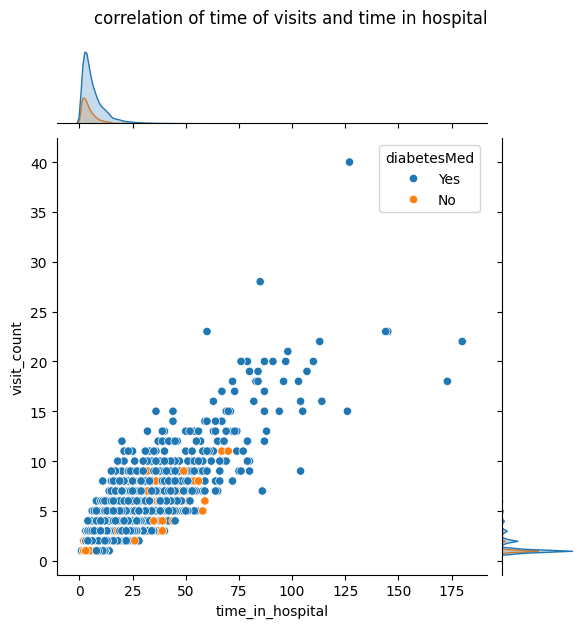

In [52]:
#plot each patient's count of visit
b = sns.jointplot(data=df_patient,
                y='visit_count',
                x='time_in_hospital',
                #col='race',
                hue='diabetesMed')
                #bins=8,
                #kind='line',
                #jitter=True)
                #palette="pastel")
                #height=4.5)
b.fig.suptitle('correlation of time of visits and time in hospital',y=1.04)


In general, the time patients stay in hospital is correlated to the count of their visit. As per this jointplot,distrubtion skewed to the right, the patients who have serious diabetic condition, the time they spend in hospitals  is above the average.